# Week 7 - Temporal models

Hello again. Welcome to week 7! In this week, we will focus on how to model time-dependent response (or target) variables (continuous or discrete!) in STAN/Pyro.

## Part 1: Linear dynamical system - Ancestral sampling

The usual imports...


In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pyro
import pyro.distributions as dist
from pyro.contrib.autoguide import AutoDiagonalNormal, AutoMultivariateNormal
from pyro.infer import MCMC, NUTS, HMC, SVI, Trace_ELBO
from pyro.optim import Adam, ClippedAdam

# fix random generator seed (for reproducibility of results)
np.random.seed(42)

# matplotlib options
plt.style.use('ggplot')
%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 10)

/opt/anaconda3/envs/ml/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In this part, we will use ancestral sampling to sample observations from a simple linear dynamical system:

\begin{align}
\beta &\sim \mathcal{N}(0, 0.1)\\
z*t &\sim \mathcal{N}(\beta \, z*{t-1}, \tau^2)\\
y_t &\sim \mathcal{N}(z_t, \sigma^2)
\end{align}

Again, the purpose of these is for you to get familiar with the modelling assumption in such a model and to make sure that you understand them. Furthermore, in most cases, a great thing to do for debugging your Pyro/STAN implementation of a model is to use ancestral sampling to generate some data from the model, and then try to recover the latent variables in using Pyro/STAN.

In this particular case, we would a) sample beta and some y's using ancestral sampling, and then try to b) use Pyro/STAN to recover beta from the observations y (inference). We recommend you to do b) as your **home work**, since the remaining notebooks today involve only real data, ok?


Ok, lets do the ancestral sampling for a time-series of length $T=20$ using the simple model described above.

We assume the values of tau and sigma to be given.

Notice that we also need to assign a prior to the first latent state $z_0$, e.g. $z_0 \sim \mathcal{N}(0,1)$. Why is that?


In [2]:
# assume sigma and tau to be fixed
tau = 0.1
print("tau:", tau)
sigma = 0.05
print("sigma:", sigma)

# length of the time-series
T = 20

z = np.zeros(T)  # vector to store sampled latent states
y = np.zeros(T)  # vector to store sampled observations
z[0] = np.random.normal(loc=0, scale=1)
y[0] = np.random.normal(z[0], sigma)
# TODO: ancestral sampling
beta = np.random.normal(loc=0, scale=tau)

for i in range(1, T):
    z[i] = np.random.normal(beta * z[i - 1], tau)
    y[i] = np.random.normal(z[i], sigma)


tau: 0.1
sigma: 0.05


Lets visualize the data that you've just generated:


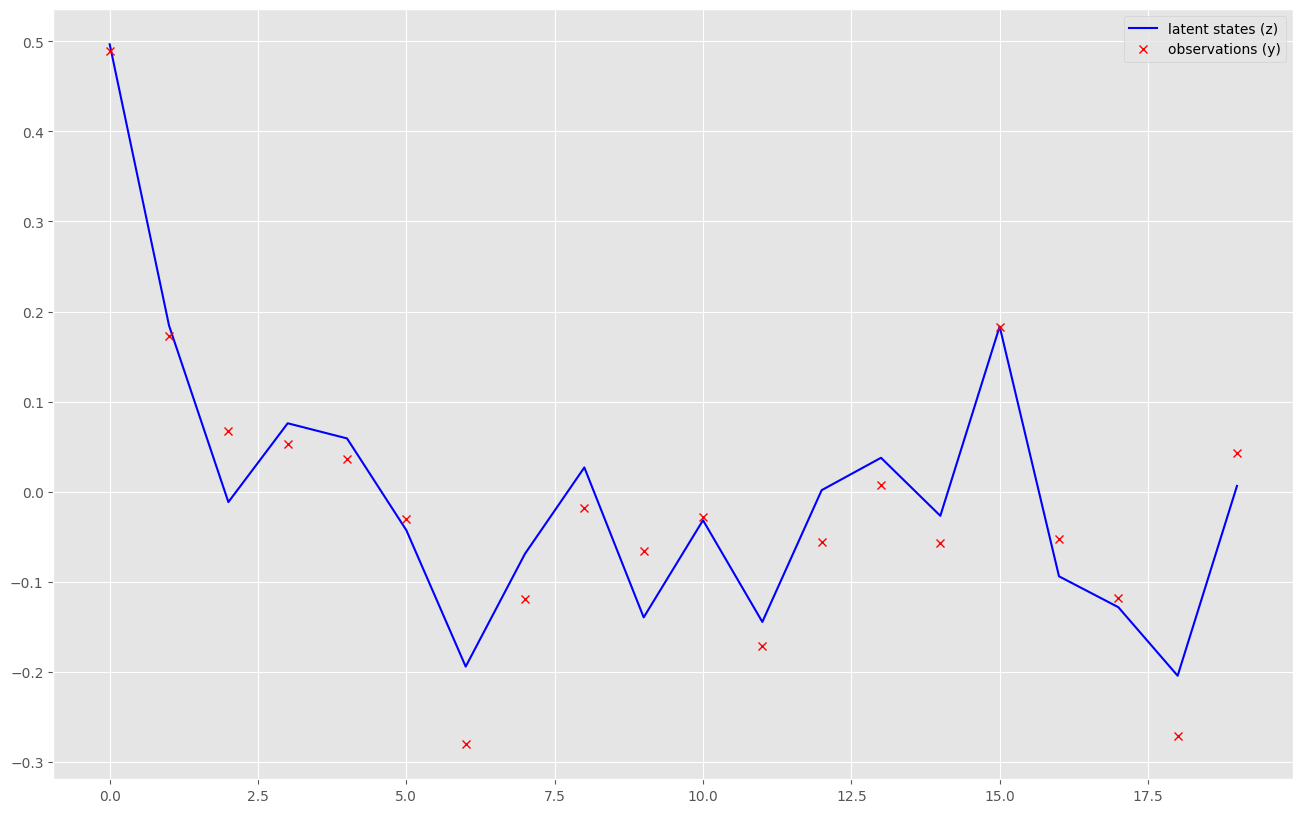

In [3]:
plt.plot(range(T), z, "b-")
plt.plot(range(T), y, "rx")
plt.legend(["latent states (z)", "observations (y)"])
plt.show()

Run the ancestral sampling code several times and look at the different results that you get. Also, make sure to play with the priors.


In [4]:
### Home work b) 
import pyro
from pyro import distributions as dist
import torch

def model(y_obs, z_obs):
    N = len(y_obs) if y_obs is not None else 20
    tau = torch.tensor(0.01)
    sigma = torch.tensor(0.05)
    beta = pyro.sample("beta", fn=dist.Normal(torch.zeros(1), 0.1 * torch.ones(1)))

    z_prev = pyro.sample("z_0", fn=dist.Normal(torch.zeros(1), torch.ones(1)), obs=z_obs[0])
    y_0 = pyro.sample("y_0", fn=dist.Normal(z[0], torch.ones(1)), obs=y_obs[0])

    with pyro.plate("data", N):
        z_curr = pyro.sample("z_i", fn=dist.Normal(beta * z_prev, tau), obs=z_obs) 
        y = pyro.sample("y_i", fn=dist.Normal(z_curr, sigma), obs=y_obs) 
        z_prev = z_curr

    return y
        

In [5]:
# Define guide function
guide = AutoDiagonalNormal(model)

# Reset parameter values
pyro.clear_param_store()

In [6]:
### Inference model
# Define the number of optimization steps

n_steps = 4000

# Setup the optimizer
adam_params = {"lr": 0.01} # learning rate (lr) of optimizer
optimizer = ClippedAdam(adam_params)

# Setup the inference algorithm
elbo = Trace_ELBO(num_particles=1)
svi = SVI(model, guide, optimizer, loss=elbo)

In [7]:
# Do gradient steps
z_torch = torch.tensor(z)
y_torch = torch.tensor(y)
for step in range(n_steps):
    elbo = svi.step(z_torch, y_torch)
    if step % 100 == 0:
        print("[%d] ELBO: %.1f" % (step, elbo))

[0] ELBO: 2829.8
[100] ELBO: 2583.2
[200] ELBO: 2611.5
[300] ELBO: 2580.5
[400] ELBO: 2579.6
[500] ELBO: 2579.4
[600] ELBO: 2578.6
[700] ELBO: 2580.4
[800] ELBO: 2580.2
[900] ELBO: 2582.6
[1000] ELBO: 2579.8
[1100] ELBO: 2580.4
[1200] ELBO: 2579.7
[1300] ELBO: 2579.6
[1400] ELBO: 2581.5
[1500] ELBO: 2579.7
[1600] ELBO: 2581.2
[1700] ELBO: 2580.7
[1800] ELBO: 2579.5
[1900] ELBO: 2579.7
[2000] ELBO: 2582.5
[2100] ELBO: 2579.8
[2200] ELBO: 2579.8
[2300] ELBO: 2580.4
[2400] ELBO: 2580.5
[2500] ELBO: 2580.0
[2600] ELBO: 2580.6
[2700] ELBO: 2581.3
[2800] ELBO: 2581.5
[2900] ELBO: 2579.8
[3000] ELBO: 2579.8
[3100] ELBO: 2580.6
[3200] ELBO: 2579.7
[3300] ELBO: 2580.0
[3400] ELBO: 2579.7
[3500] ELBO: 2579.5
[3600] ELBO: 2580.8
[3700] ELBO: 2581.2
[3800] ELBO: 2581.2
[3900] ELBO: 2579.7


In [8]:
# Here is where I wan to predict. 
from pyro.infer import Predictive
predictive = Predictive(model, guide=guide, num_samples=1000,
                        return_sites=("beta",))
samples = predictive(z_torch, y_torch)

In [9]:
print("Estimated beta:", samples["beta"].mean(axis=0).detach().numpy()[0])
print("Estimated beta:", samples["beta"])

Estimated beta: -0.01608059
Estimated beta: tensor([[-0.0133],
        [-0.0090],
        [-0.0145],
        [-0.0112],
        [-0.0210],
        [-0.0227],
        [-0.0193],
        [-0.0096],
        [-0.0236],
        [-0.0178],
        [-0.0105],
        [-0.0221],
        [-0.0155],
        [-0.0099],
        [-0.0217],
        [-0.0114],
        [-0.0150],
        [-0.0139],
        [-0.0160],
        [-0.0211],
        [-0.0161],
        [-0.0146],
        [-0.0131],
        [-0.0177],
        [-0.0131],
        [-0.0267],
        [-0.0096],
        [-0.0174],
        [-0.0135],
        [-0.0143],
        [-0.0053],
        [-0.0185],
        [-0.0206],
        [-0.0150],
        [-0.0203],
        [-0.0152],
        [-0.0137],
        [-0.0108],
        [-0.0255],
        [-0.0108],
        [-0.0127],
        [-0.0053],
        [-0.0217],
        [-0.0166],
        [-0.0249],
        [-0.0152],
        [-0.0130],
        [-0.0169],
        [-0.0116],
        [-0.0131],
      

(array([ 1.,  0.,  0.,  0.,  1.,  5.,  1.,  2.,  2.,  3.,  4.,  9.,  9.,
        15., 16., 15., 16., 19., 32., 34., 34., 43., 34., 43., 38., 51.,
        48., 60., 54., 50., 44., 36., 58., 41., 26., 30., 25., 32., 16.,
        13., 11.,  8.,  7.,  3.,  2.,  3.,  3.,  1.,  0.,  2.]),
 array([-0.03108029, -0.03052683, -0.02997336, -0.02941989, -0.02886642,
        -0.02831295, -0.02775948, -0.02720601, -0.02665255, -0.02609908,
        -0.02554561, -0.02499214, -0.02443867, -0.0238852 , -0.02333174,
        -0.02277827, -0.0222248 , -0.02167133, -0.02111786, -0.02056439,
        -0.02001092, -0.01945746, -0.01890399, -0.01835052, -0.01779705,
        -0.01724358, -0.01669011, -0.01613664, -0.01558318, -0.01502971,
        -0.01447624, -0.01392277, -0.0133693 , -0.01281583, -0.01226236,
        -0.0117089 , -0.01115543, -0.01060196, -0.01004849, -0.00949502,
        -0.00894155, -0.00838809, -0.00783462, -0.00728115, -0.00672768,
        -0.00617421, -0.00562074, -0.00506727, -0.0045138 ,

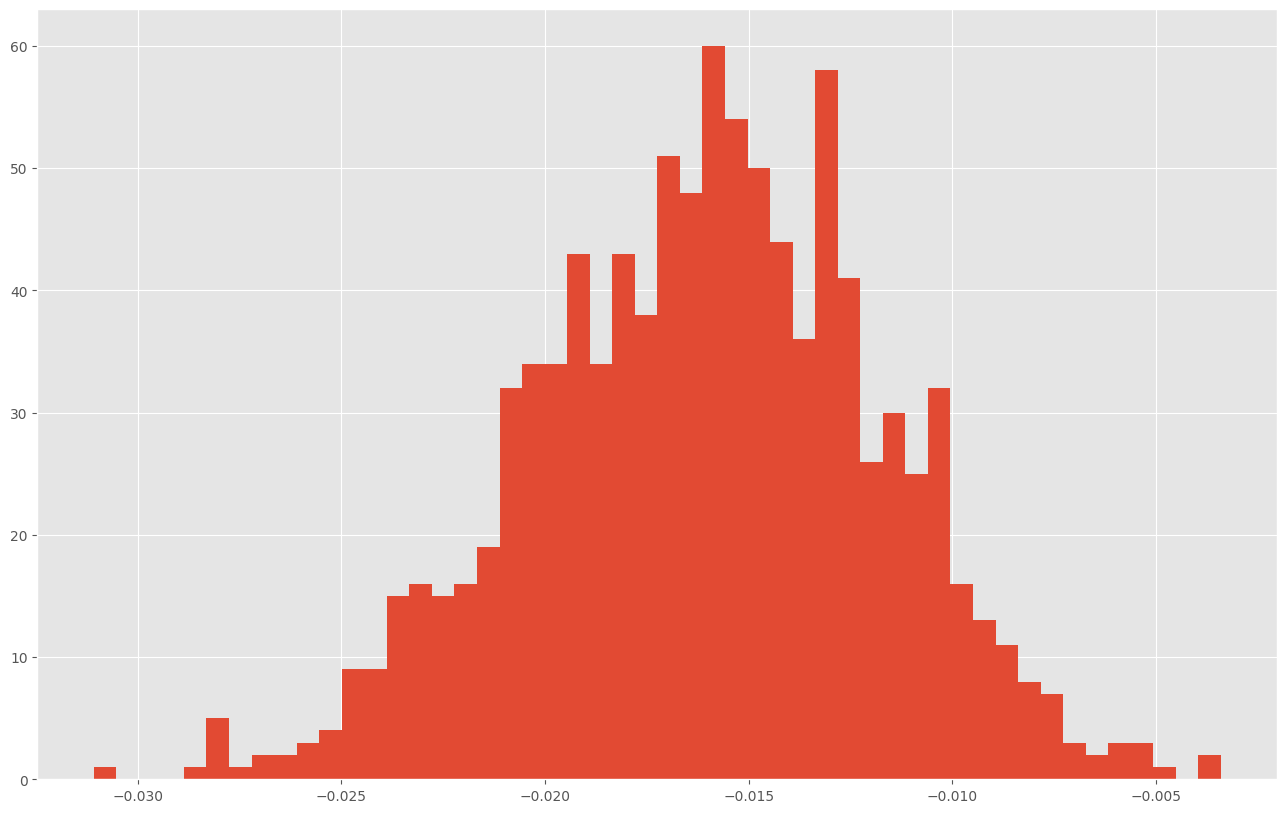

In [10]:
beta_samples = samples["beta"]
plt.hist(beta_samples, bins=50)


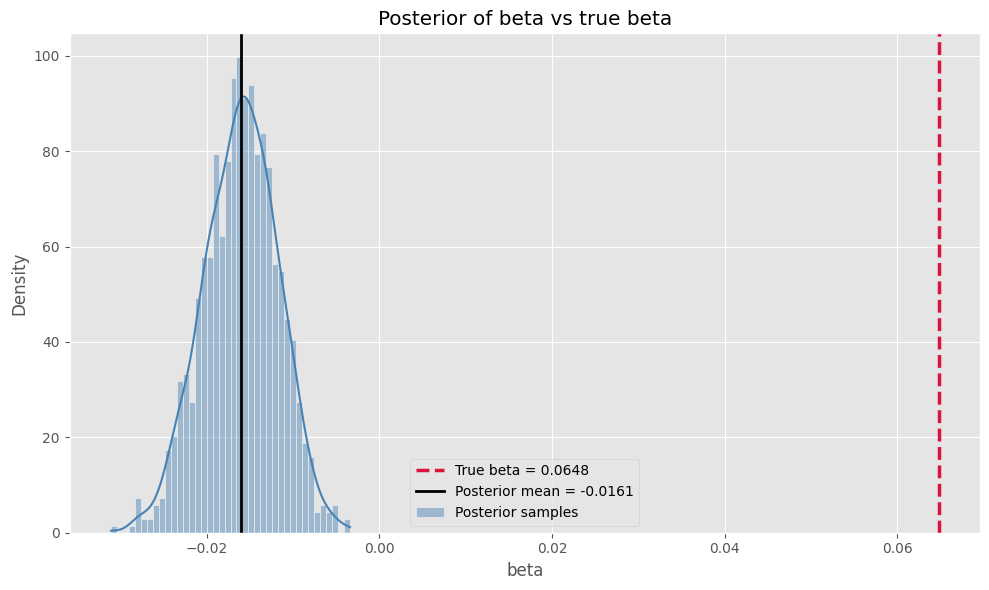

In [11]:
# Posterior plot of beta with seaborn + true beta overlay (copy/paste in one cell)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# If beta is a torch tensor, convert for label formatting
true_beta = beta.item() if hasattr(beta, "item") else float(beta)

# Extract posterior samples from Predictive output
beta_samples = samples["beta"].detach().cpu().numpy().reshape(-1)

# Plot
plt.figure(figsize=(10, 6))
sns.histplot(beta_samples, bins=40, stat="density", kde=True, color="steelblue", alpha=0.45, label="Posterior samples")
plt.axvline(true_beta, color="crimson", linestyle="--", linewidth=2.5, label=f"True beta = {true_beta:.4f}")
plt.axvline(beta_samples.mean(), color="black", linestyle="-", linewidth=2, label=f"Posterior mean = {beta_samples.mean():.4f}")

plt.title("Posterior of beta vs true beta")
plt.xlabel("beta")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()